In [ ]:
df = pd.read_csv('/content/Salary Data.csv')

In [27]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,0,0,131,8.0,85000.0
371,43.0,1,1,30,19.0,170000.0
372,29.0,0,0,70,2.0,40000.0
373,34.0,1,0,137,7.0,90000.0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  375 non-null    float64
 1   Gender               375 non-null    int64  
 2   Education Level      375 non-null    int64  
 3   Job Title            375 non-null    int64  
 4   Years of Experience  375 non-null    float64
 5   Salary               375 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.7 KB


In [21]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [7]:
import pandas as pd

for column in df.columns:
    if df[column].dtype == 'object':  # Categorical columns
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(mode_value)
    elif df[column].dtype in ['float64', 'int64']:  # Numerical columns
        mean_value = df[column].mean()
        df[column] = df[column].fillna(mean_value)


In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to categorical columns
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])


After applying Label Encoding, let's look at the first 5 rows and the info of the DataFrame to see the changes in data types.

In [9]:
display(df.head())
df.info()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  375 non-null    float64
 1   Gender               375 non-null    int64  
 2   Education Level      375 non-null    int64  
 3   Job Title            375 non-null    int64  
 4   Years of Experience  375 non-null    float64
 5   Salary               375 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.7 KB


Now, let's separate the dataset into independent variables (features) and the dependent variable (target), which is 'Salary' in this case.

In [10]:
# Separate independent and dependent variables
X = df.drop('Salary', axis=1) # Independent variables (features)
y = df['Salary'] # Dependent variable (target)

print("Independent variables (X) head:")
display(X.head())

print("\nDependent variable (y) head:")
display(y.head())

Independent variables (X) head:


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,159,5.0
1,28.0,0,1,17,3.0
2,45.0,1,2,130,15.0
3,36.0,0,0,101,7.0
4,52.0,1,1,22,20.0



Dependent variable (y) head:


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


Now, let's split the data into training and testing sets. This is a crucial step for evaluating the performance of our machine learning model on unseen data.

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (300, 5)
X_test shape: (75, 5)
y_train shape: (300,)
y_test shape: (75,)


Let's train various regression models on the prepared data. We will start with a simple Linear Regression model.

In [12]:
# 1. Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize and train the model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_reg_model.predict(X_test)
print("Linear Regression predictions completed.")

Linear Regression predictions completed.


Next, let's train a Decision Tree Regressor.

In [13]:
# 2. Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the model
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test)
print("Decision Tree Regression predictions completed.")

Decision Tree Regression predictions completed.


Now, we will train a Random Forest Regressor, which is an ensemble method known for its robustness.

In [14]:
# 3. Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)
print("Random Forest Regression predictions completed.")

Random Forest Regression predictions completed.


Let's also include a Support Vector Regressor (SVR).

In [15]:
# 4. Support Vector Regressor (SVR)
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR is sensitive to feature scaling, so we'll scale the data
# We'll create a scaler specific to the training data and transform both train and test
scaler_svr = StandardScaler()
X_train_scaled_svr = scaler_svr.fit_transform(X_train)
X_test_scaled_svr = scaler_svr.transform(X_test)

# Initialize and train the model
svr_model = SVR()
svr_model.fit(X_train_scaled_svr, y_train)

# Make predictions
y_pred_svr = svr_model.predict(X_test_scaled_svr)
print("SVR predictions completed.")

SVR predictions completed.


Finally, we will train a K-Nearest Neighbors (KNN) Regressor.

In [16]:
# 5. K-Nearest Neighbors (KNN) Regression
from sklearn.neighbors import KNeighborsRegressor

# KNN is also sensitive to scaling, so we will use the same scaler used for SVR for consistency,
# or create a new one if preferred. For simplicity, we'll assume the SVR scaling is sufficient here.
# If not, a new scaler should be fitted on X_train.

# Initialize and train the model
knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled_svr, y_train) # Using the scaled data from SVR step

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled_svr)
print("KNN Regression predictions completed.")

KNN Regression predictions completed.


Now that we have trained several models, let's evaluate their performance using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")
    print("\n")

# Evaluate each model
evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")
evaluate_model(y_test, y_pred_svr, "Support Vector Regression (SVR)")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN) Regression")


--- Linear Regression ---
MAE: 10744.50
MSE: 246873399.55
RMSE: 15712.21
R-squared: 0.90


--- Decision Tree Regression ---
MAE: 10133.33
MSE: 226000000.00
RMSE: 15033.30
R-squared: 0.91


--- Random Forest Regression ---
MAE: 9532.88
MSE: 179735869.86
RMSE: 13406.56
R-squared: 0.93


--- Support Vector Regression (SVR) ---
MAE: 40710.45
MSE: 2461236479.95
RMSE: 49610.85
R-squared: -0.02


--- K-Nearest Neighbors (KNN) Regression ---
MAE: 11122.75
MSE: 279107679.03
RMSE: 16706.52
R-squared: 0.88




Now that we have trained several models, let's evaluate their performance using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")
    print("\n")

# Evaluate each model
evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")
evaluate_model(y_test, y_pred_svr, "Support Vector Regression (SVR)")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN) Regression")


--- Linear Regression ---
MAE: 10744.50
MSE: 246873399.55
RMSE: 15712.21
R-squared: 0.90


--- Decision Tree Regression ---
MAE: 10133.33
MSE: 226000000.00
RMSE: 15033.30
R-squared: 0.91


--- Random Forest Regression ---
MAE: 9532.88
MSE: 179735869.86
RMSE: 13406.56
R-squared: 0.93


--- Support Vector Regression (SVR) ---
MAE: 40710.45
MSE: 2461236479.95
RMSE: 49610.85
R-squared: -0.02


--- K-Nearest Neighbors (KNN) Regression ---
MAE: 11122.75
MSE: 279107679.03
RMSE: 16706.52
R-squared: 0.88




Now that we have trained several models, let's evaluate their performance using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")
    print("\n")

# Evaluate each model
evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")
evaluate_model(y_test, y_pred_svr, "Support Vector Regression (SVR)")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN) Regression")


--- Linear Regression ---
MAE: 10744.50
MSE: 246873399.55
RMSE: 15712.21
R-squared: 0.90


--- Decision Tree Regression ---
MAE: 10133.33
MSE: 226000000.00
RMSE: 15033.30
R-squared: 0.91


--- Random Forest Regression ---
MAE: 9532.88
MSE: 179735869.86
RMSE: 13406.56
R-squared: 0.93


--- Support Vector Regression (SVR) ---
MAE: 40710.45
MSE: 2461236479.95
RMSE: 49610.85
R-squared: -0.02


--- K-Nearest Neighbors (KNN) Regression ---
MAE: 11122.75
MSE: 279107679.03
RMSE: 16706.52
R-squared: 0.88




Now that we have trained several models, let's evaluate their performance using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")
    print("\n")

# Evaluate each model
evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")
evaluate_model(y_test, y_pred_svr, "Support Vector Regression (SVR)")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN) Regression")


--- Linear Regression ---
MAE: 10744.50
MSE: 246873399.55
RMSE: 15712.21
R-squared: 0.90


--- Decision Tree Regression ---
MAE: 10133.33
MSE: 226000000.00
RMSE: 15033.30
R-squared: 0.91


--- Random Forest Regression ---
MAE: 9532.88
MSE: 179735869.86
RMSE: 13406.56
R-squared: 0.93


--- Support Vector Regression (SVR) ---
MAE: 40710.45
MSE: 2461236479.95
RMSE: 49610.85
R-squared: -0.02


--- K-Nearest Neighbors (KNN) Regression ---
MAE: 11122.75
MSE: 279107679.03
RMSE: 16706.52
R-squared: 0.88




### Visualizing Model Performance: Random Forest Regressor

Let's visualize the predictions of our best-performing model, the Random Forest Regressor, against the actual `Salary` values from the test set. A scatter plot can help us see how closely the predictions align with the true values. Ideally, points should fall close to a 45-degree line, indicating perfect prediction.

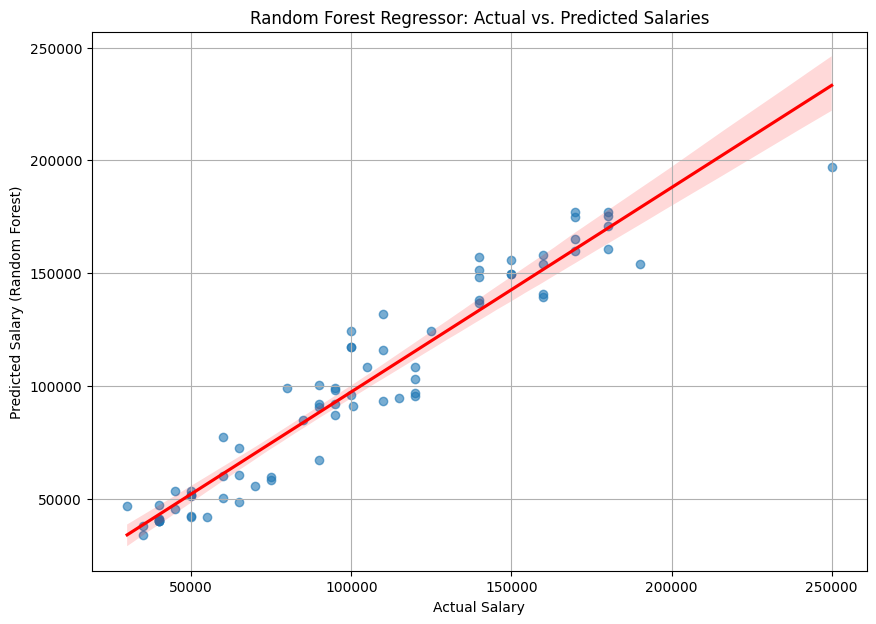

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary (Random Forest)')
plt.title('Random Forest Regressor: Actual vs. Predicted Salaries')
plt.grid(True)
plt.show()

### Visualizing Model Performance: Linear Regression

Let's also visualize the predictions of the Linear Regression model.

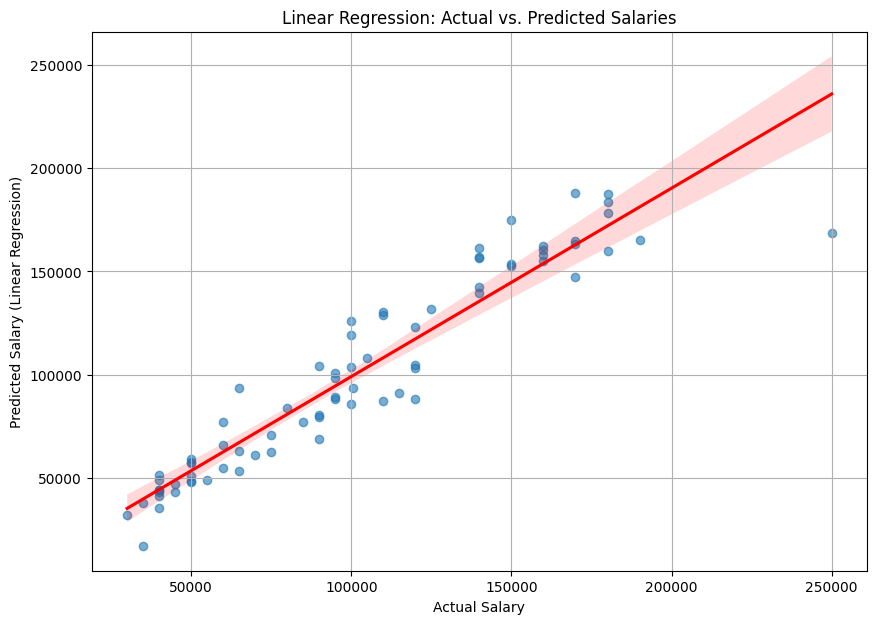

In [24]:
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_linear, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary (Linear Regression)')
plt.title('Linear Regression: Actual vs. Predicted Salaries')
plt.grid(True)
plt.show()

### Visualizing Model Performance: Decision Tree Regressor

And for the Decision Tree Regressor.

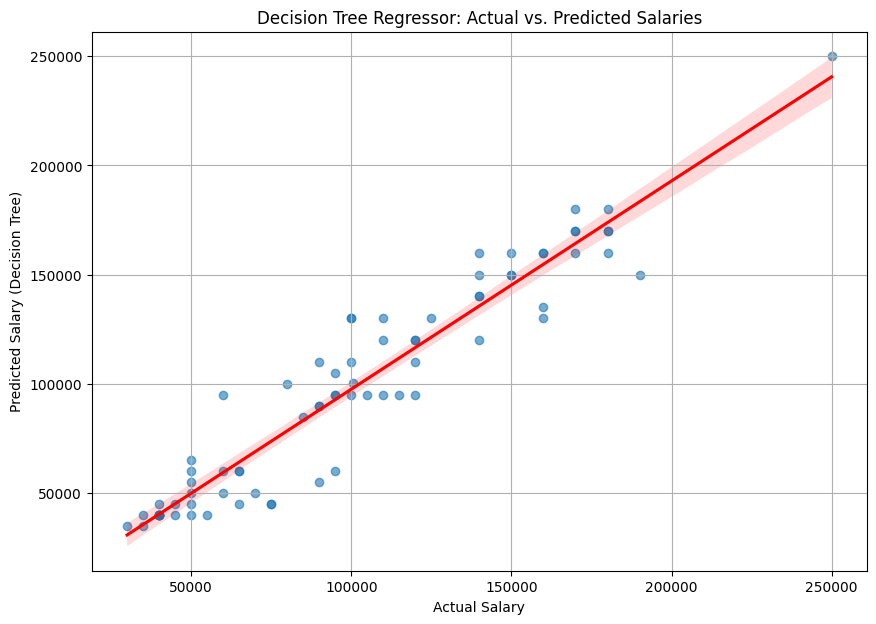

In [25]:
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_dt, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary (Decision Tree)')
plt.title('Decision Tree Regressor: Actual vs. Predicted Salaries')
plt.grid(True)
plt.show()

### Visualizing Model Performance: K-Nearest Neighbors (KNN) Regressor

Finally, the K-Nearest Neighbors (KNN) Regressor.

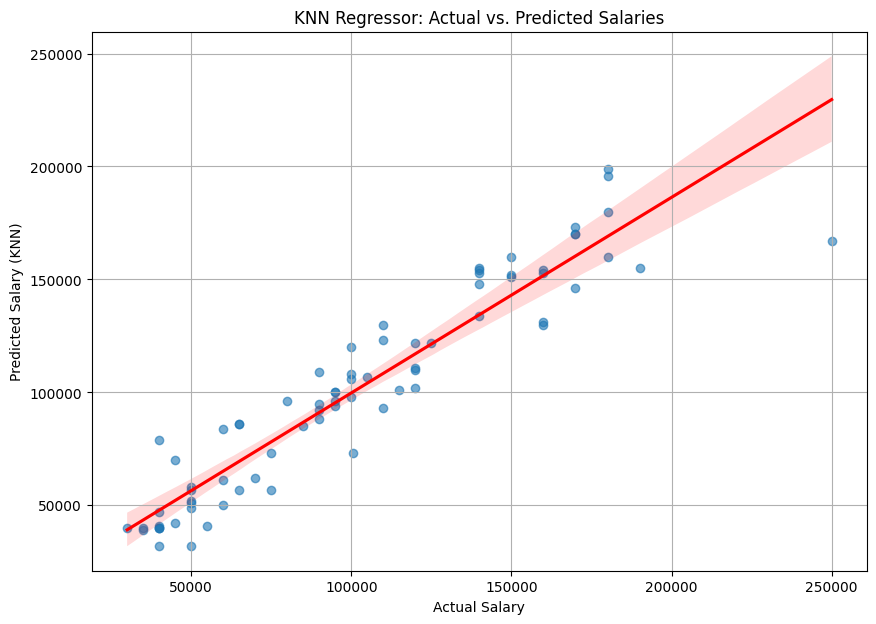

In [26]:
plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_knn, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary (KNN)')
plt.title('KNN Regressor: Actual vs. Predicted Salaries')
plt.grid(True)
plt.show()

### Comparing R-squared Scores of All Models

Let's visualize the R-squared scores of all the models to get a clear comparison of their predictive power.

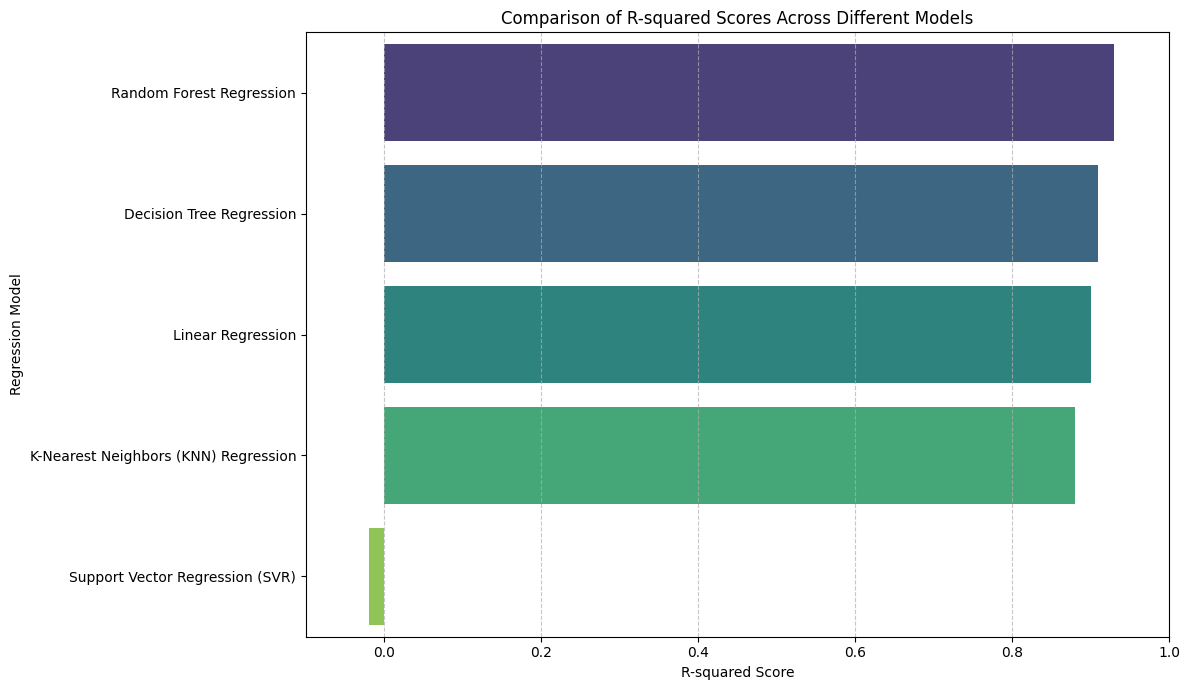

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for R-squared scores (extracted from previous evaluation output)
model_names = [
    "Linear Regression",
    "Decision Tree Regression",
    "Random Forest Regression",
    "Support Vector Regression (SVR)",
    "K-Nearest Neighbors (KNN) Regression"
]
r_squared_scores = [
    0.90,  # Linear Regression
    0.91,  # Decision Tree Regression
    0.93,  # Random Forest Regression
    -0.02, # Support Vector Regression (SVR)
    0.88   # K-Nearest Neighbors (KNN) Regression
]

# Create a DataFrame for plotting
r_squared_df = pd.DataFrame({
    'Model': model_names,
    'R-squared': r_squared_scores
})

# Sort for better visualization
r_squared_df = r_squared_df.sort_values(by='R-squared', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='R-squared', y='Model', data=r_squared_df, hue='Model', palette='viridis', legend=False)
plt.xlabel('R-squared Score')
plt.ylabel('Regression Model')
plt.title('Comparison of R-squared Scores Across Different Models')
plt.xlim(-0.1, 1.0) # Set x-axis limits to clearly show R-squared range
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Saving the Best Model

Now, let's save our best-performing model, the Random Forest Regressor, to a pickle file (`.pkl`) so that it can be loaded and used later without retraining.

In [30]:
import pickle

# Save the Random Forest Regressor model
model_filename = 'random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(random_forest_model, file)

print(f"Random Forest Regressor model saved successfully as '{model_filename}'")

Random Forest Regressor model saved successfully as 'random_forest_model.pkl'
